In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib as pl
import unicodedata,re

In [34]:
directory = pl.Path("/Users/subhakarpant/Downloads/archive")

def clean_txt(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"\s", " ", text).strip()
    return text

data =[]

for item in directory.iterdir():
    if not item.is_dir():
        continue
    
    label = item.name
    
    for file in item.rglob("*.txt"):
        try:
            text = file.read_text(encoding="utf-8")
        except UnicodeDecodeError:
            text = file.read_text(encoding="utf-8", errors="ignore")
        
        text = clean_txt(text)
        
        if text: 
            data.append({
                "text": text,
                "label": label
            })

df = pd.DataFrame(data)

print(df.head())

                                                text            label
0  कम्प्युटरबाट तेस्रो विश्वयुद्धअमेरिकाले तेस्रो...  SuchanaPrabidhi
1  सामाजिक सञ्जालबाट अपराधफेसबुक र टि्वटरजस्ता सम...  SuchanaPrabidhi
2  प्रविधिका प्रभावशाली महिलाविश्वका ठूला प्रविधि...  SuchanaPrabidhi
3  गुगलले चीनमा गीत डाउनलोड सेवा बन्द गर्नेगुगलले...  SuchanaPrabidhi
4  लेनोभोको आइडिया प्याड आयो"मेगाटेकले लेनोभोको प...  SuchanaPrabidhi


In [35]:
print(df["label"].value_counts())

label
SuchanaPrabidhi    1000
Manoranjan         1000
Prabas             1000
Bichar             1000
ArthaBanijya       1000
Desh               1000
Swasthya           1000
Khelkud            1000
Viswa              1000
Sahitya            1000
Name: count, dtype: int64


In [36]:
df.shape

(10000, 2)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10000 non-null  object
 1   label   10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [38]:
X = df["text"]
y = df["label"]

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42
)
X_train.shape, X_test.shape

((8000,), (2000,))

In [40]:
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [41]:
pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=100000),
    MultinomialNB()
)
param_grid = {
    'multinomialnb__alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

# Grid search
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best alpha: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_*100:.2f}%")

# Use best model
best_pipe = grid_search.best_estimator_
y_preds = best_pipe.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_preds)*100:.2f}%")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha: {'multinomialnb__alpha': 0.1}
Best cross-validation accuracy: 83.71%
Test accuracy: 84.00%


In [42]:
print(f'Classification Report\n{classification_report(y_test,y_preds)}')

Classification Report
                 precision    recall  f1-score   support

   ArthaBanijya       0.76      0.89      0.82       209
         Bichar       0.77      0.94      0.85       201
           Desh       0.90      0.76      0.83       186
        Khelkud       0.99      0.95      0.97       204
     Manoranjan       0.78      0.72      0.75       202
         Prabas       0.84      0.74      0.79       192
        Sahitya       0.71      0.80      0.75       175
SuchanaPrabidhi       0.91      0.85      0.88       208
       Swasthya       0.92      0.94      0.93       211
          Viswa       0.86      0.79      0.82       212

       accuracy                           0.84      2000
      macro avg       0.84      0.84      0.84      2000
   weighted avg       0.85      0.84      0.84      2000



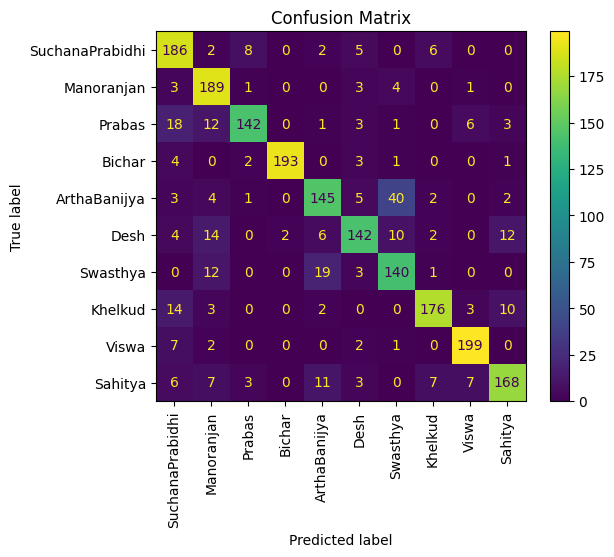

In [63]:
cm = confusion_matrix(y_test,y_preds)
cm_plot = ConfusionMatrixDisplay(confusion_matrix= cm,
                                 display_labels= df['label'].unique())
cm_plot.plot()
plt.xticks(rotation = 90)
plt.title("Confusion Matrix")
plt.savefig('cm.png')
plt.show()


In [64]:
import joblib
joblib.dump(best_pipe,"nepali_news_classifier.joblib")

['nepali_news_classifier.joblib']